Code-only notebook. All explanations, derivations and result interpretations: `13_project_report.ipynb`, section "Notebook 15 - Exact finite-shot counting model".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

from qsv.data_generation import create_dataset
from qsv.features import extract_amplitudes, sigma_from_shots
from qsv.tomography import (
    conditional_probabilities,
    estimate_norm_squared,
    sample_counts,
    validate_counts,
)

RANDOM_STATE = 42
MARGIN = 0.05
%matplotlib inline


def random_state(dim, rng):
    v = rng.normal(size=dim) + 1j * rng.normal(size=dim)
    return v / np.linalg.norm(v)


def counting_estimates(psi, n_shots, reps, rng):
    """reps independent realisations of the counting experiment."""
    lam = n_shots * np.abs(psi) ** 2
    return rng.poisson(lam, size=(reps, psi.size)).sum(axis=1) / n_shots


def gaussian_estimates(psi, n_shots, reps, rng):
    """Same quantity under the current Gaussian amplitude-noise model."""
    sigma = sigma_from_shots(n_shots)
    re = psi.real + rng.normal(0, sigma, size=(reps, psi.size))
    im = psi.imag + rng.normal(0, sigma, size=(reps, psi.size))
    return (re**2 + im**2).sum(axis=1)


In [2]:
# Bias and spread of the counting estimator, against the two theoretical laws
rng = np.random.default_rng(RANDOM_STATE)
REPS = 200_000

print(f"{'d':>3} {'N':>6} {'true':>7} {'E[est]':>10} {'bias':>11} "
      f"{'sd':>9} {'sqrt(n2/N)':>11}")
for d in (2, 4, 8):
    psi0 = random_state(d, rng)
    for n2 in (0.90, 1.00, 1.10):
        psi = psi0 * np.sqrt(n2)
        for N in (100, 1000):
            est = counting_estimates(psi, N, REPS, rng)
            print(f"{d:>3} {N:>6} {n2:>7.2f} {est.mean():>10.5f} "
                  f"{est.mean() - n2:>+11.2e} {est.std():>9.5f} "
                  f"{np.sqrt(n2 / N):>11.5f}")


  d      N    true     E[est]        bias        sd  sqrt(n2/N)
  2    100    0.90    0.89978   -2.22e-04   0.09479     0.09487
  2   1000    0.90    0.90001   +7.83e-06   0.02999     0.03000
  2    100    1.00    0.99965   -3.49e-04   0.09994     0.10000
  2   1000    1.00    0.99984   -1.61e-04   0.03163     0.03162
  2    100    1.10    1.10018   +1.85e-04   0.10490     0.10488
  2   1000    1.10    1.10005   +4.71e-05   0.03312     0.03317
  4    100    0.90    0.90002   +2.14e-05   0.09475     0.09487


  4   1000    0.90    0.89997   -2.81e-05   0.03005     0.03000
  4    100    1.00    1.00030   +2.96e-04   0.09987     0.10000
  4   1000    1.00    1.00009   +8.50e-05   0.03165     0.03162
  4    100    1.10    1.10023   +2.34e-04   0.10476     0.10488
  4   1000    1.10    1.10003   +3.23e-05   0.03315     0.03317


  8    100    0.90    0.89973   -2.69e-04   0.09478     0.09487
  8   1000    0.90    0.89998   -2.38e-05   0.03001     0.03000
  8    100    1.00    1.00001   +1.37e-05   0.10011     0.10000


  8   1000    1.00    1.00002   +1.76e-05   0.03156     0.03162
  8    100    1.10    1.09955   -4.53e-04   0.10514     0.10488
  8   1000    1.10    1.10010   +1.02e-04   0.03323     0.03317


  d      N   bias gauss  2 d sigma^2   bias count
  2    100     +0.00984      0.01000     -0.00017
  2    400     +0.00256      0.00250     -0.00006
  2   1600     +0.00063      0.00063     +0.00008
  4    100     +0.01965      0.02000     +0.00007
  4    400     +0.00502      0.00500     -0.00004
  4   1600     +0.00127      0.00125     +0.00008
  8    100     +0.04016      0.04000     -0.00008
  8    400     +0.01016      0.01000     -0.00022
  8   1600     +0.00248      0.00250     -0.00002
 16    100     +0.08018      0.08000     +0.00010
 16    400     +0.01990      0.02000     -0.00017
 16   1600     +0.00500      0.00500     +0.00004


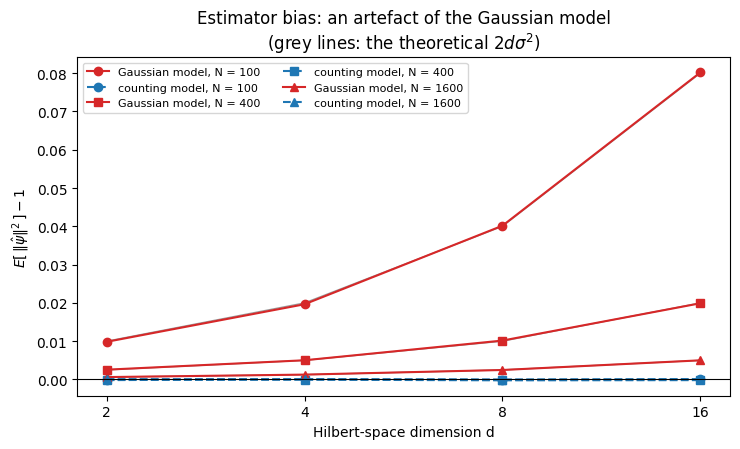

In [3]:
# The 2*d*sigma^2 term: present in the Gaussian model, absent from counting
rng = np.random.default_rng(RANDOM_STATE)
REPS = 200_000
dims, budgets = (2, 4, 8, 16), (100, 400, 1600)

bias_g, bias_c, bias_th = {}, {}, {}
for d in dims:
    psi = random_state(d, rng)
    for N in budgets:
        sigma = sigma_from_shots(N)
        bias_g[(d, N)] = gaussian_estimates(psi, N, REPS, rng).mean() - 1.0
        bias_c[(d, N)] = counting_estimates(psi, N, REPS, rng).mean() - 1.0
        bias_th[(d, N)] = 2 * d * sigma**2

print(f"{'d':>3} {'N':>6} {'bias gauss':>12} {'2 d sigma^2':>12} {'bias count':>12}")
for d in dims:
    for N in budgets:
        print(f"{d:>3} {N:>6} {bias_g[(d, N)]:>+12.5f} "
              f"{bias_th[(d, N)]:>12.5f} {bias_c[(d, N)]:>+12.5f}")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for N, mk in zip(budgets, ("o", "s", "^")):
    ax.plot(dims, [bias_th[(d, N)] for d in dims], "-", color="0.6", lw=1)
    ax.plot(dims, [bias_g[(d, N)] for d in dims], mk + "-", color="tab:red",
            label=f"Gaussian model, N = {N}")
    ax.plot(dims, [bias_c[(d, N)] for d in dims], mk + "--", color="tab:blue",
            label=f"counting model, N = {N}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xscale("log", base=2)
ax.set_xticks(dims)
ax.set_xticklabels(dims)
ax.set_xlabel("Hilbert-space dimension d")
ax.set_ylabel(r"$E[\,\|\hat\psi\|^2\,] - 1$")
ax.set_title("Estimator bias: an artefact of the Gaussian model\n"
             "(grey lines: the theoretical $2d\\sigma^2$)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


counting : mean = 0.99991  sd = 0.04980
gaussian : mean = 1.00486  sd = 0.05001
2 d sigma^2 = 0.00500


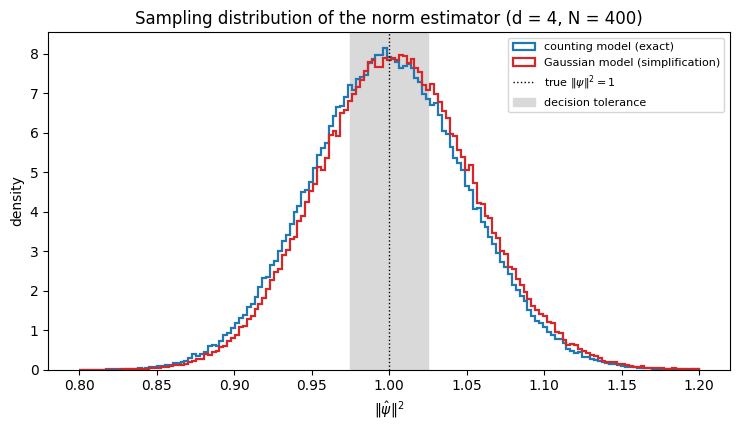

In [4]:
# Sampling distribution at d = 4, N = 400: same spread, shifted centre
rng = np.random.default_rng(RANDOM_STATE)
d, N, REPS = 4, 400, 200_000
psi = random_state(d, rng)
est_c = counting_estimates(psi, N, REPS, rng)
est_g = gaussian_estimates(psi, N, REPS, rng)

print(f"counting : mean = {est_c.mean():.5f}  sd = {est_c.std():.5f}")
print(f"gaussian : mean = {est_g.mean():.5f}  sd = {est_g.std():.5f}")
print(f"2 d sigma^2 = {2 * d * sigma_from_shots(N) ** 2:.5f}")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
bins = np.linspace(0.8, 1.2, 160)
ax.hist(est_c, bins=bins, histtype="step", color="tab:blue", lw=1.6,
        density=True, label="counting model (exact)")
ax.hist(est_g, bins=bins, histtype="step", color="tab:red", lw=1.6,
        density=True, label="Gaussian model (simplification)")
ax.axvline(1.0, color="k", ls=":", lw=1, label=r"true $\|\psi\|^2 = 1$")
ax.axvspan(1 - MARGIN / 2, 1 + MARGIN / 2, color="0.85", zorder=0,
           label="decision tolerance")
ax.set_xlabel(r"$\|\hat\psi\|^2$")
ax.set_ylabel("density")
ax.set_title(f"Sampling distribution of the norm estimator (d = {d}, N = {N})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


conditional frequencies k / sum(k), N = 400000
  ||psi||^2 = 0.85 -> [0.473  0.3383 0.07   0.1187]   total =  339017
  ||psi||^2 = 1.00 -> [0.473  0.3382 0.07   0.1188]   total =  398934
  ||psi||^2 = 1.20 -> [0.473  0.3381 0.07   0.1189]   total =  478832
  exact |c_i|^2 / ||psi||^2 = [0.4732 0.337  0.0703 0.1195]


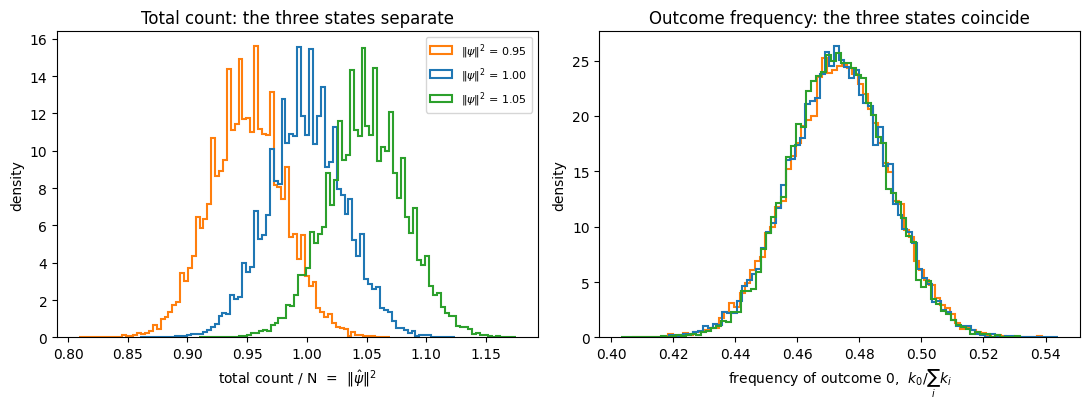

In [5]:
# Where the norm information lives: total count vs outcome frequencies
rng = np.random.default_rng(RANDOM_STATE)
d = 4
psi = random_state(d, rng)
exact = np.abs(psi) ** 2

print("conditional frequencies k / sum(k), N = 400000")
for n2 in (0.85, 1.00, 1.20):
    s = psi * np.sqrt(n2)
    counts = sample_counts(s.real, s.imag, n_shots=400_000, seed=11)
    print(f"  ||psi||^2 = {n2:.2f} -> {np.round(conditional_probabilities(counts), 4)}"
          f"   total = {counts.sum():>7d}")
print(f"  exact |c_i|^2 / ||psi||^2 = {np.round(exact, 4)}")

REPS, N = 20_000, 1000
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for n2, color in ((0.95, "tab:orange"), (1.00, "tab:blue"), (1.05, "tab:green")):
    s = psi * np.sqrt(n2)
    counts = rng.poisson(N * np.abs(s) ** 2, size=(REPS, d))
    axes[0].hist(counts.sum(axis=1) / N, bins=80, histtype="step", lw=1.5,
                 density=True, color=color, label=rf"$\|\psi\|^2$ = {n2:.2f}")
    freq0 = counts[:, 0] / counts.sum(axis=1)
    axes[1].hist(freq0, bins=80, histtype="step", lw=1.5, density=True, color=color)
axes[0].set_xlabel(r"total count / N  =  $\|\hat\psi\|^2$")
axes[0].set_title("Total count: the three states separate")
axes[0].legend(fontsize=8)
axes[1].set_xlabel(r"frequency of outcome 0,  $k_0 / \sum_i k_i$")
axes[1].set_title("Outcome frequency: the three states coincide")
for ax in axes:
    ax.set_ylabel("density")
plt.tight_layout()
plt.show()


FPR = invalid accepted, FNR = valid rejected (notebook-12 convention)
     N |  FPR gauss  FNR gauss |  FPR count  FNR count
    25 |     0.0105     0.9012 |     0.0047     0.9177
   100 |     0.0090     0.8037 |     0.0088     0.7907
   400 |     0.0043     0.6140 |     0.0040     0.6170
  1600 |     0.0010     0.3100 |     0.0018     0.3202
  6400 |     0.0000     0.0442 |     0.0000     0.0447
 25600 |     0.0000     0.0003 |     0.0000     0.0003


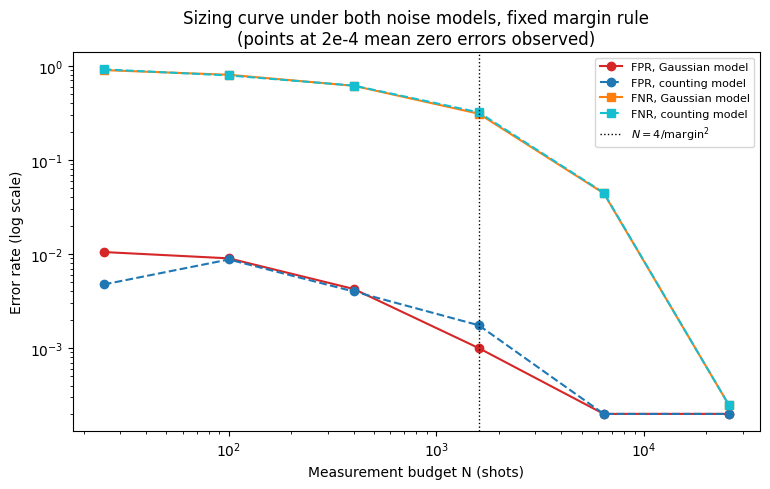

In [6]:
# Sizing curve of notebook 12, recomputed under the exact counting model
df = create_dataset(4000, 4000, dim=4, seed=RANDOM_STATE)
states = extract_amplitudes(df)
lam_unit = np.abs(states) ** 2
y = df["is_valid"].to_numpy().astype(bool)
DIM = 4
budgets = (25, 100, 400, 1600, 6400, 25600)

rows = {}
for N in budgets:
    rng = np.random.default_rng(RANDOM_STATE)
    sigma = sigma_from_shots(N)
    thr = MARGIN / 2

    re = states.real + rng.normal(0, sigma, size=states.shape)
    im = states.imag + rng.normal(0, sigma, size=states.shape)
    acc_g = np.abs((re**2 + im**2).sum(axis=1) - 1.0 - 2 * DIM * sigma**2) <= thr

    acc_c = np.abs(rng.poisson(N * lam_unit).sum(axis=1) / N - 1.0) <= thr

    rows[N] = (acc_g[~y].mean(), (~acc_g[y]).mean(),
               acc_c[~y].mean(), (~acc_c[y]).mean())

print("FPR = invalid accepted, FNR = valid rejected (notebook-12 convention)")
print(f"{'N':>6} | {'FPR gauss':>10} {'FNR gauss':>10} | "
      f"{'FPR count':>10} {'FNR count':>10}")
for N in budgets:
    fg, ng, fc, nc = rows[N]
    print(f"{N:>6} | {fg:>10.4f} {ng:>10.4f} | {fc:>10.4f} {nc:>10.4f}")

fig, ax = plt.subplots(figsize=(7.8, 5))
eps = 2e-4
ax.plot(budgets, [max(rows[N][0], eps) for N in budgets], "o-", color="tab:red",
        label="FPR, Gaussian model")
ax.plot(budgets, [max(rows[N][2], eps) for N in budgets], "o--", color="tab:blue",
        label="FPR, counting model")
ax.plot(budgets, [max(rows[N][1], eps) for N in budgets], "s-", color="tab:orange",
        label="FNR, Gaussian model")
ax.plot(budgets, [max(rows[N][3], eps) for N in budgets], "s--", color="tab:cyan",
        label="FNR, counting model")
ax.axvline(4 / MARGIN**2, color="k", ls=":", lw=1,
           label=r"$N = 4/\mathrm{margin}^2$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Measurement budget N (shots)")
ax.set_ylabel("Error rate (log scale)")
ax.set_title("Sizing curve under both noise models, fixed margin rule\n"
             "(points at 2e-4 mean zero errors observed)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# The decision itself, on counting data
rng = np.random.default_rng(RANDOM_STATE)
psi = random_state(4, rng)

for N in (400, 6400):
    for n2, label in ((1.00, "valid"), (1.00 - MARGIN, "invalid -"),
                      (1.00 + MARGIN, "invalid +"), (1.30, "invalid, far")):
        s = psi * np.sqrt(n2)
        counts = sample_counts(s.real, s.imag, n_shots=N, seed=5)
        r = validate_counts(counts, N, margin=MARGIN)
        print(f"N = {N:>5}  {label:<12} ||psi_hat||^2 = {r.norm_squared:>7.4f}  "
              f"valid = {str(r.valid):<5}  p = {r.p_value:>9.3g}  "
              f"budget_ok = {r.budget_ok}")
    print()

est = estimate_norm_squared(sample_counts(psi.real, psi.imag, 6400, seed=5), 6400)
print(f"point estimate {est.value:.4f} +/- {est.std_error:.4f} (1 sd), "
      f"{est.total_counts} clicks for N = {est.n_shots}")
print()
print(validate_counts(sample_counts(psi.real, psi.imag, 400, seed=5), 400).explanation)


N =   400  valid        ||psi_hat||^2 =  1.0025  valid = True   p =     0.973  budget_ok = False
N =   400  invalid -    ||psi_hat||^2 =  0.9525  valid = False  p =     0.356  budget_ok = False
N =   400  invalid +    ||psi_hat||^2 =  1.0500  valid = False  p =     0.329  budget_ok = False
N =   400  invalid, far ||psi_hat||^2 =  1.3025  valid = False  p =  8.26e-09  budget_ok = False

N =  6400  valid        ||psi_hat||^2 =  1.0003  valid = True   p =     0.983  budget_ok = True
N =  6400  invalid -    ||psi_hat||^2 =  0.9503  valid = False  p =  6.33e-05  budget_ok = True
N =  6400  invalid +    ||psi_hat||^2 =  1.0503  valid = False  p =  6.67e-05  budget_ok = True
N =  6400  invalid, far ||psi_hat||^2 =  1.3005  valid = False  p = 1.18e-116  budget_ok = True

point estimate 1.0003 +/- 0.0125 (1 sd), 6402 clicks for N = 6400

Counting model: 401 clicks for a calibrated exposure of N = 400, so ||psi_hat||^2 = 1.0025 +/- 0.0501 (1 sd). The deviation from 1 is 0.0025, compatible with t